https://github.com/Onurbltc/HotelData/blob/main/HotelData.xlsx

Dataset HotelData.xlsx (thường được biết đến rộng rãi với tên gọi Hotel Booking Demand Dataset) là một trong những bộ dữ liệu kinh điển dùng cho các bài toán Phân tích dữ liệu (EDA) và Học máy (Machine Learning), đặc biệt là bài toán Dự đoán khả năng hủy phòng của khách hàng (Cancellation Prediction).

. Tổng quan về DatasetQuy mô: Gồm khoảng hơn 119.000 dòng dữ liệu tương ứng với các lượt đặt phòng thực tế tại khách sạn.Loại khách sạn: Bao gồm 2 loại chính:City Hotel (Khách sạn thành phố): Thường có tỷ lệ khách đặt ngắn ngày và thay đổi nhiều hơn.   Resort Hotel (Khách sạn nghỉ dưỡng): Thường có xu hướng đặt phòng dài ngày hơn vào các dịp nghỉ lễ/cuối tuần.   Mục tiêu chính (Target): Cột is_canceled (0: Không hủy phòng, 1: Đã hủy phòng).   

2. Giải chi tiết các nhóm cột dữ liệu quan trọngBộ dữ liệu chứa khoảng 32 đến 36 cột, được chia thành các nhóm chính sau:A. Thông tin về Đặt phòng & Thời gian (Booking & Time)hotel: Loại khách sạn ("City Hotel" hoặc "Resort Hotel").   is_canceled: Biến mục tiêu (Target) - Khách có hủy phòng hay không (1: Có, 0: Không).   lead_time: Số ngày tính từ ngày khách đặt phòng đến ngày khách chính thức nhận phòng (Arrival Date). Lead time càng cao thì khả năng hủy phòng thường càng lớn.   arrival_date_year / month / week_number / day_of_month: Thời gian chi tiết ngày khách đến. Giúp phân tích mùa vụ (mùa cao điểm/thấp điểm).   stays_in_weekend_nights: Số đêm cuối tuần (Thứ Bảy, Chủ Nhật) khách ở lại.   stays_in_week_nights: Số đêm trong tuần (Từ Thứ Hai đến Thứ Sáu) khách ở lại.   B. Thông tin về Khách hàng & Thành phần (Guests & Demographics)adults, children, babies: Số lượng người lớn, trẻ em và em bé đi cùng.   meal: Loại gói ăn uống được đặt (ví dụ: BB - Bed & Breakfast, HB - Half Board, FB - Full Board, SC - Self Catering/Không ăn).   country: Quất tịch của khách hàng (Mã quốc gia dạng ISO). Thường dùng để vẽ bản đồ phân bố khách quốc tế.   market_segment: Phân khúc thị trường (ví dụ: Direct - Đặt trực tiếp, Corporate - Khách doanh nghiệp, TA/TO - Đại lý du lịch/Lữ hành).   distribution_channel: Kênh phân phối phòng (qua bên thứ ba, trực tiếp, hay qua mạng lưới công ty).   is_repeated_guest: Khách hàng cũ hay khách hàng mới (1: Khách quay lại, 0: Khách lần đầu).   C. Lịch sử giao dịch & Chính sách (History & Policies)previous_cancellations: Số lần khách đã từng hủy phòng trong quá khứ trước đó. Đây là một trong những "feature" quan trọng nhất để dự đoán hủy phòng.   previous_bookings_not_canceled: Số lần đặt phòng trước đây không bị hủy.   booking_changes: Số lần khách thay đổi/chỉnh sửa thông tin đặt phòng kể từ lúc đặt đến lúc nhận phòng.   deposit_type: Hình thức đặt cọc (No Deposit - Không cọc, Non Refund - Không hoàn tiền, Refundable - Có thể hoàn tiền). Khám phá xem loại đặt cọc nào có tỷ lệ hủy cao nhất.   days_in_waiting_list: Số ngày đơn đặt phòng phải nằm trong danh sách chờ trước khi được xác nhận.   D. Tài chính & Tiện ích bổ sung (Financials & Extras)adr (Average Daily Rate): Giá phòng trung bình tính trên mỗi ngày đêm. Dùng để tính doanh thu.   required_car_parking_spaces: Số lượng chỗ đậu xe ô tô mà khách yêu cầu thêm.   total_of_special_requests: Tổng số các yêu cầu đặc biệt của khách (ví dụ: tầng cao, giường đôi, view đẹp,...). Khách có nhiều yêu cầu đặc biệt thường ít có xu hướng hủy phòng hơn.   reservation_status: Trạng thái cuối cùng của đơn (Canceled, Check-Out, No-Show).   

3. Hướng triển khai Project với Dataset nàyNếu bạn đang xây dựng project cho dataset này, các bước tiêu chuẩn thường làm là:Tiền xử lý dữ liệu (Data Preprocessing):Xử lý giá trị thiếu (Missing values) thường nằm ở các cột company, agent, country, children.Mã hóa các biến chữ (Categorical variables) như hotel, meal, market_segment, deposit_type sang dạng số bằng One-Hot Encoding hoặc Label Encoding.Khám phá dữ liệu (EDA):   Vẽ biểu đồ xem tháng nào trong năm có lượng đặt phòng cao nhất?Tỷ lệ hủy phòng (is_canceled) giữa City Hotel và Resort Hotel khác nhau thế nào?   Khách đặt phòng qua kênh nào có tỷ lệ hủy cao nhất?Xây dựng mô hình Machine Learning (Classification):Các thuật toán thường dùng: Random Forest, XGBoost, LightGBM, Logistic Regression.Đánh giá mô hình qua các chỉ số: Accuracy, Precision, Recall, F1-Score, và ROC-AUC (do dữ liệu hủy phòng thường bị mất cân bằng - imbalanced dataset).

In [1]:
import pandas as pd
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel("HotelData.xlsx")

In [4]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,Canceled
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,Not_Canceled
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,Canceled
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,Not_Canceled


In [5]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled


In [6]:
df.dtypes

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

để kiểm tra kiểu dữ liệu của từng cột trong DataFrame (df).

In [7]:
df.shape

(25811, 16)

In [8]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000
mean,1.890744,0.142265,0.883034,2.263918,0.042424,65.548836,2017.850490,7.331099,15.752780,0.033009,0.028747,0.214676,105.747677,0.746426
std,0.529264,0.464034,0.887990,1.514417,0.201558,67.452796,0.356597,3.143281,8.854341,0.178664,0.410378,2.075722,37.916084,0.815896
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,12.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.750000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,44.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,100.000000,1.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,98.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,127.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [9]:
df.describe(include="object")

,type_of_meal_plan,booking_status
count,25811,25811
unique,4,2
top,Meal Plan 1,Not_Canceled
freq,20265,18542


để thống kê mô tả nhanh cho các cột chứa dữ liệu dạng chữ (object / categorical) trong DataFrame của bạn (ví dụ như tên loại phòng, phân khúc khách hàng, quốc tịch,...).

Khác với lệnh df.describe() mặc định (chỉ thống kê cho các cột số), việc thêm tham số include="object" sẽ giúp bạn khai thác riêng các thông tin đặc thù của dữ liệu phân loại

In [10]:
df["booking_status"].value_counts()

booking_status
Not_Canceled    18542
Canceled         7269
Name: count, dtype: int64

In [11]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled


In [12]:
df["total_guests"] = df["no_of_adults"] + df["no_of_children"]

tạo một cột mới tên là total_guests (Tổng số khách) bằng cách cộng dồn giá trị của hai cột no_of_adults (Số người lớn) và no_of_children (Số trẻ em) trong DataFrame.

In [13]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled,2
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled,2
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled,1
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled,2


In [14]:
df["total_nights"] = df["no_of_weekend_nights"] + df["no_of_week_nights"]

tạo một cột mới tên là total_nights (Tổng số đêm lưu trú) bằng cách cộng tổng số đêm cuối tuần (no_of_weekend_nights) với số đêm trong tuần (no_of_week_nights).

In [15]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled,2,3
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled,2,5
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled,1,3
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled,2,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled,2,2


In [16]:
df["booking_status"].value_counts(normalize=True)

booking_status
Not_Canceled    0.718376
Canceled        0.281624
Name: proportion, dtype: float64

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

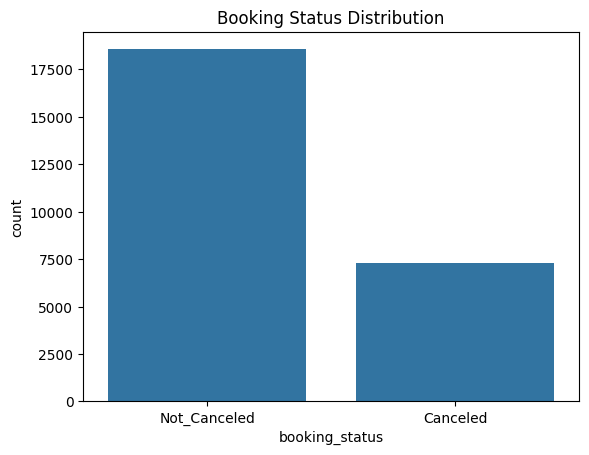

In [18]:
sns.countplot(data=df, x="booking_status")
plt.title("Booking Status Distribution")
plt.show()

In [19]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [20]:
num_cols

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'total_guests',
       'total_nights'],
      dtype='object')

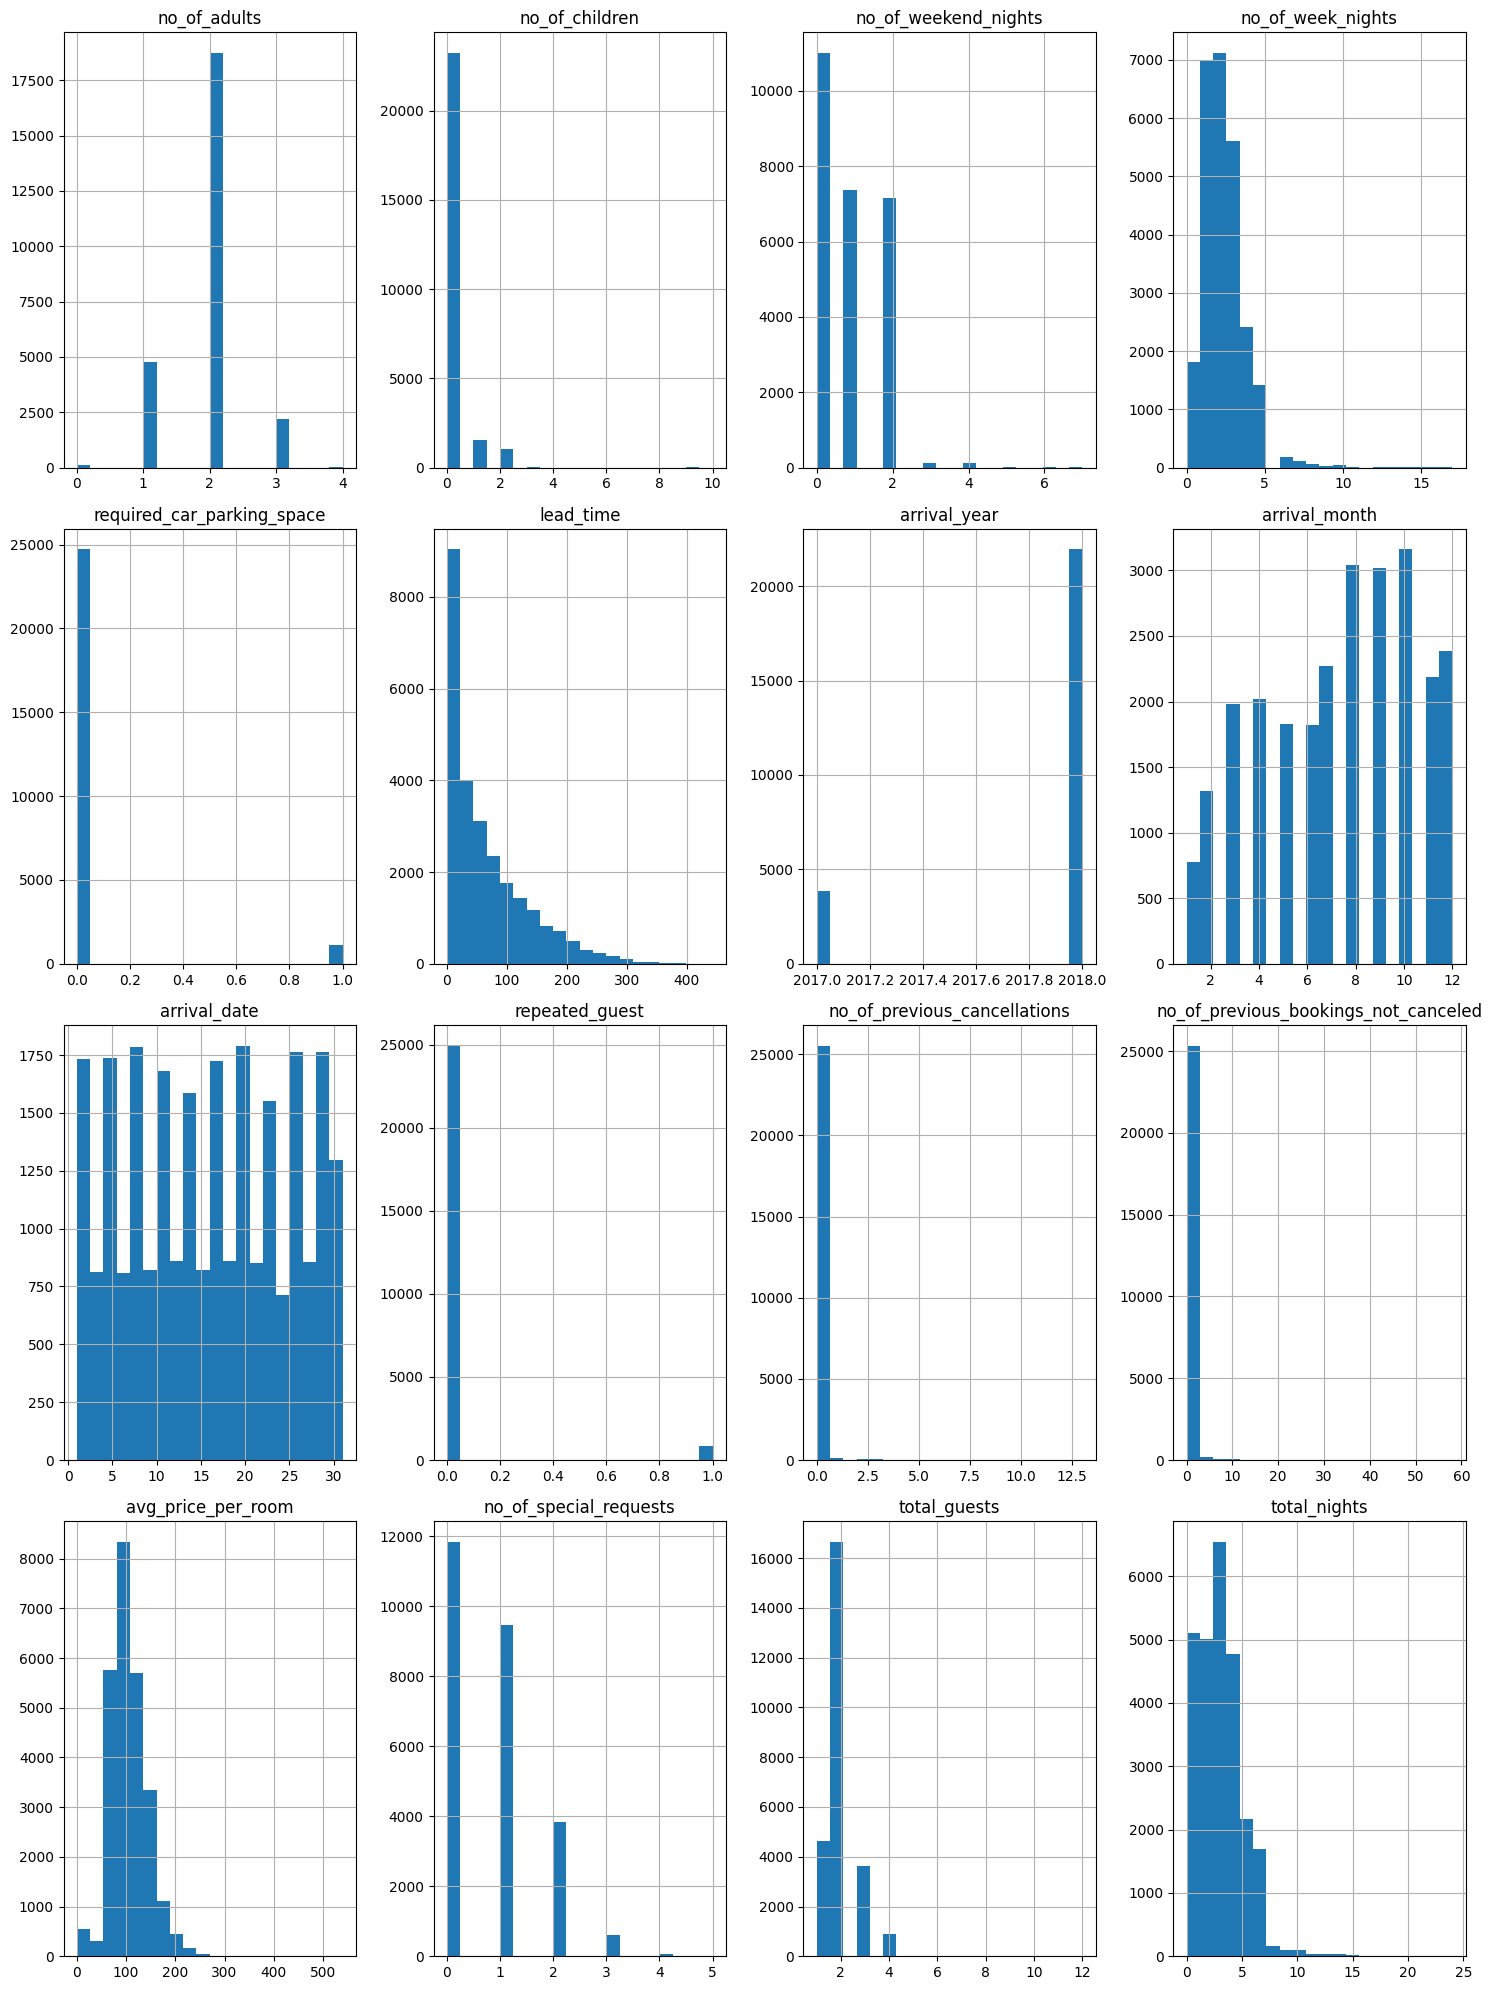

In [21]:
df[num_cols].hist(figsize=(15,20), bins=20)
plt.tight_layout()
plt.show()

để vẽ biểu đồ phân phối (histogram) cho tất cả các cột dữ liệu dạng số (num_cols) có trong DataFrame của bạn, giúp bạn trực quan hóa nhanh hình thái phân phối của từng biến.

Kiểm tra độ lệch dữ liệu (Skewness): Giúp bạn nhận biết nhanh xem dữ liệu có bị lệch nhiều về bên trái hay bên phải không (ví dụ: cột lead_time thường bị lệch phải vì đa số khách đặt sát ngày, nhưng có một số ít khách đặt trước cả năm).

Phát hiện giá trị bất thường (Outliers): Nhìn vào biểu đồ, bạn sẽ thấy ngay nếu có các cột xuất hiện giá trị quá xa so với phần còn lại (ví dụ: giá phòng avg_price đột nhiên có một vài điểm vút lên cực cao hoặc có số âm).

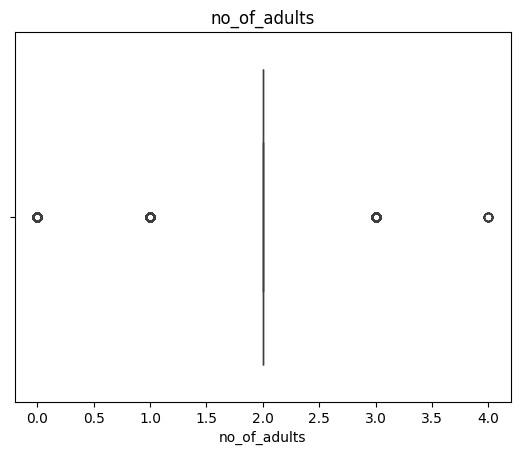

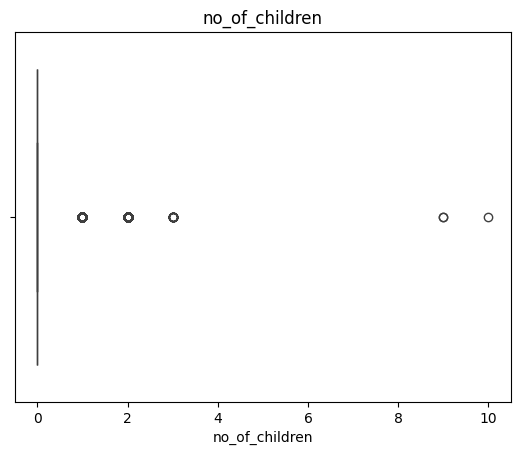

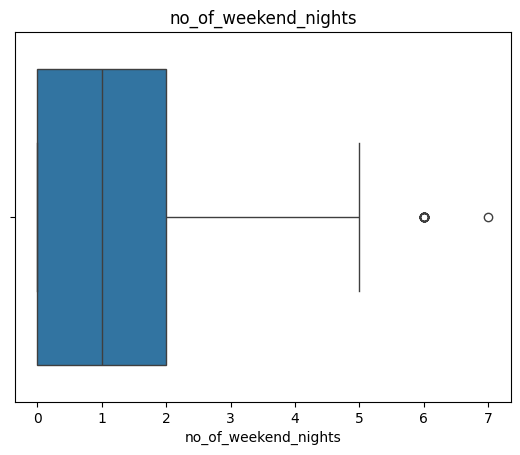

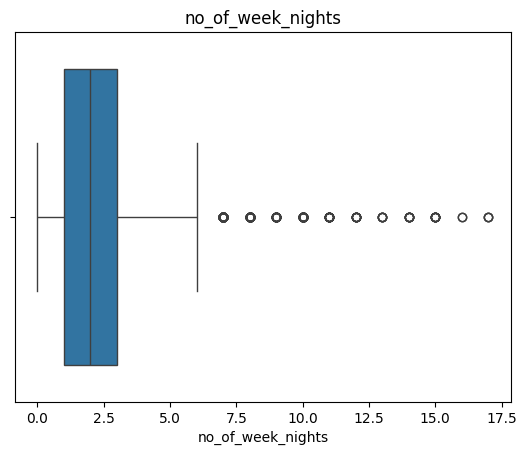

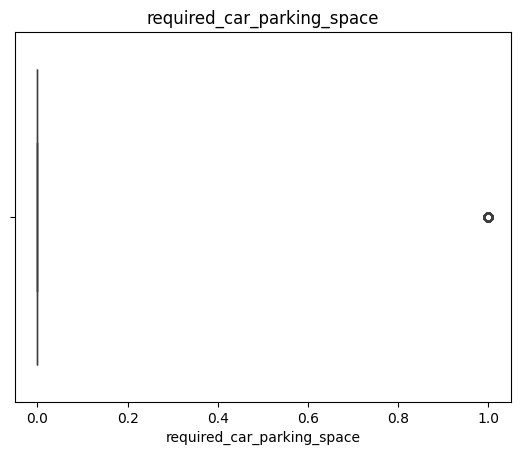

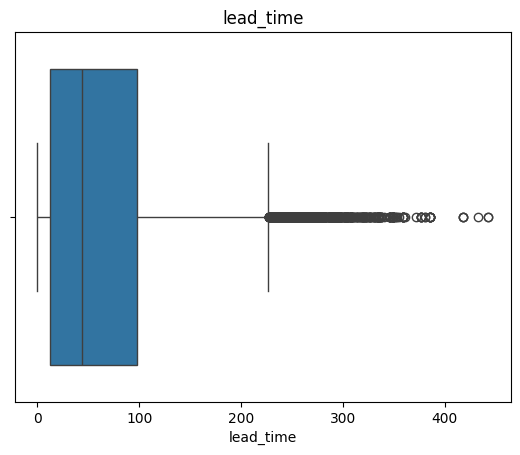

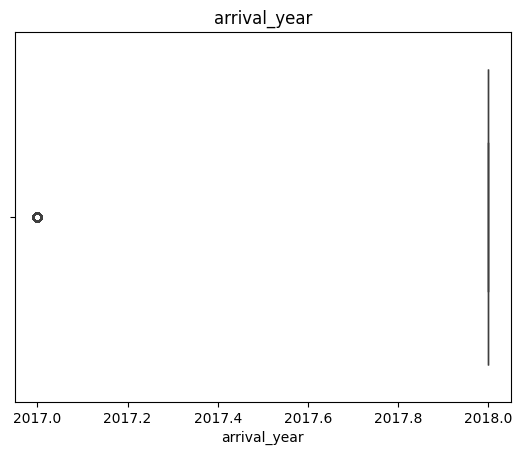

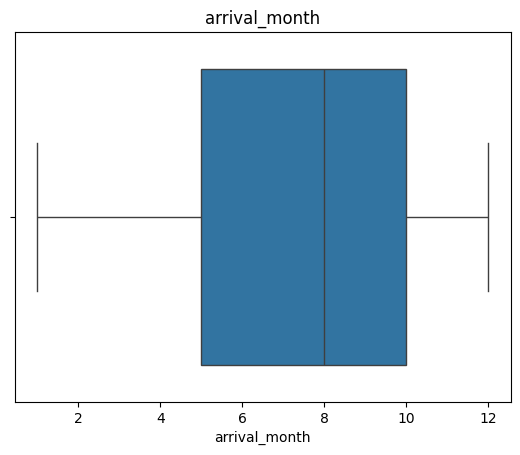

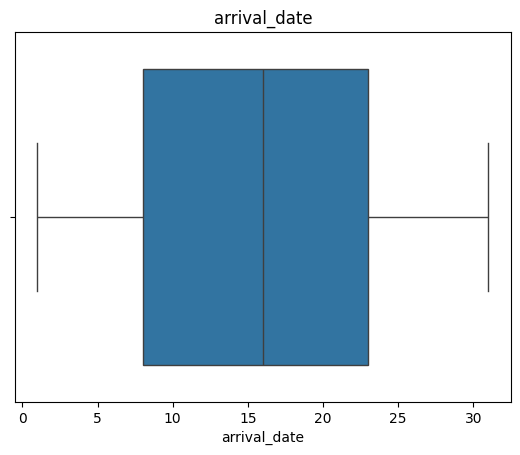

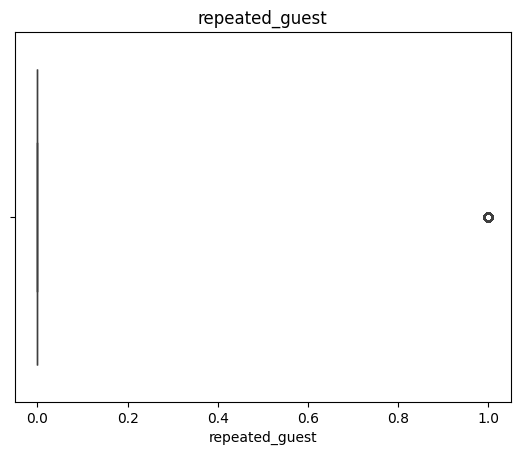

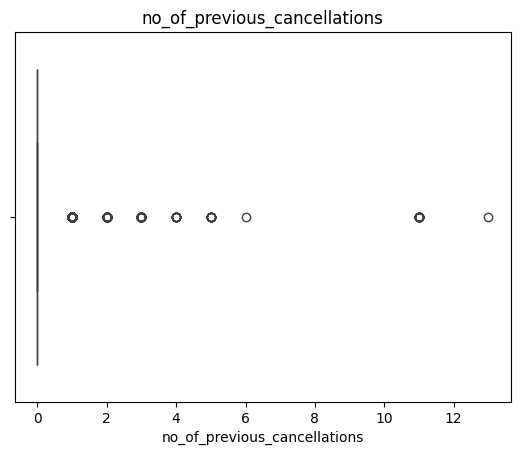

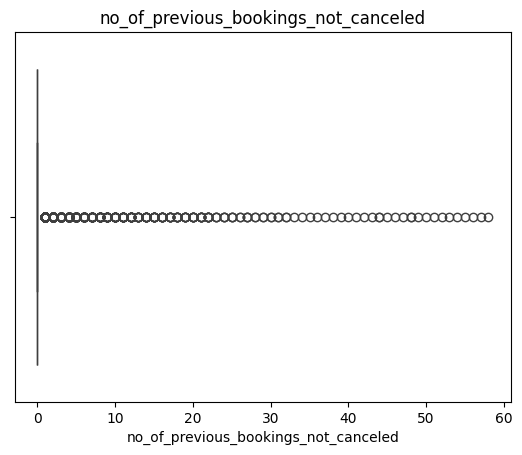

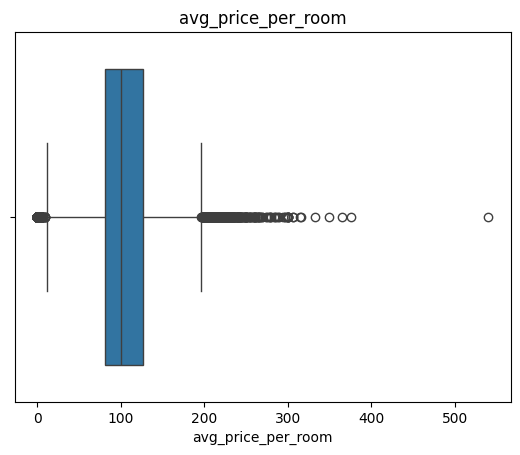

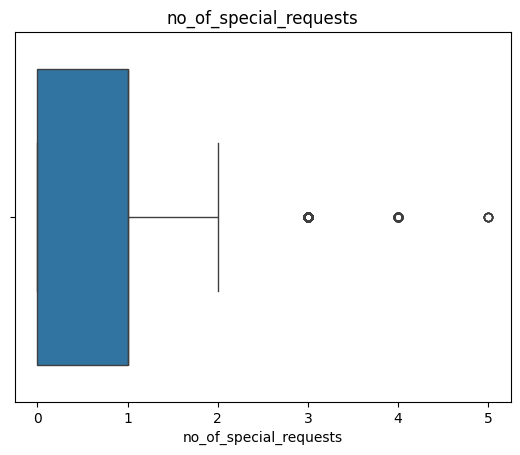

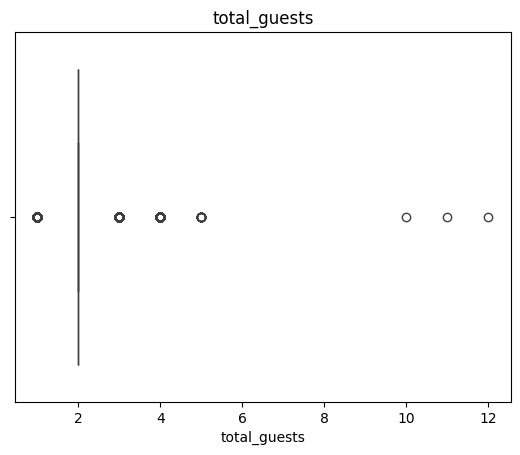

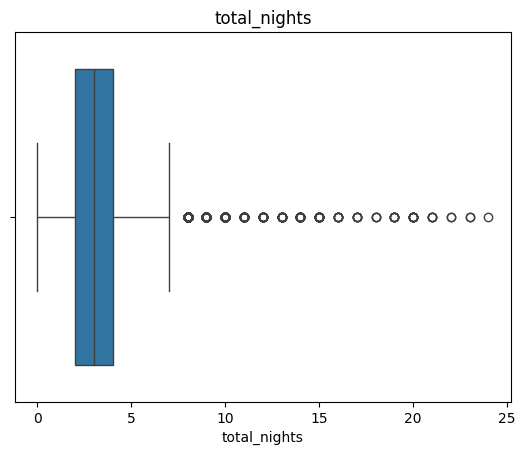

In [22]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x = df[col])
    plt.title(col)

In [23]:
df.groupby("booking_status")["lead_time"].mean()

booking_status
Canceled        104.366488
Not_Canceled     50.331194
Name: lead_time, dtype: float64

dùng để tính giá trị trung bình của số ngày đặt trước (lead_time) theo từng trạng thái đặt phòng (booking_status).

In [24]:
df.groupby("booking_status")["avg_price_per_room"].mean()

booking_status
Canceled        115.347719
Not_Canceled    101.984183
Name: avg_price_per_room, dtype: float64

dùng để tính giá trung bình mỗi phòng (avg_price_per_room) theo từng trạng thái đặt phòng (booking_status).

In [25]:
df.groupby("booking_status")["total_guests"].mean()

booking_status
Canceled        2.163434
Not_Canceled    1.981879
Name: total_guests, dtype: float64

dùng để tính tổng số lượng khách trung bình (total_guests) theo từng trạng thái đặt phòng (booking_status).

In [26]:
df.groupby(["type_of_meal_plan", "booking_status"]).size().unstack()

booking_status,Canceled,Not_Canceled
type_of_meal_plan,,
Meal Plan 1,5500,14765
Meal Plan 2,368,710
Meal Plan 3,1,4
Not Selected,1400,3063


tạo bảng chéo (cross-tabulation/contingency table) đếm số lượng bản ghi theo từng loại hình suất ăn (type_of_meal_plan) ứng với từng trạng thái đặt phòng (booking_status).

In [27]:
pivot_price = pd.pivot_table(
    df,
    values="avg_price_per_room",
    index ="arrival_month",
    columns="booking_status",
    aggfunc="mean"
)

tạo một bảng tổng hợp (pivot table) nhằm tính giá phòng trung bình (avg_price_per_room) theo từng tháng đến khách sạn (arrival_month), đồng thời tách riêng theo từng trạng thái đặt phòng (booking_status).

In [28]:
pivot_price

booking_status,Canceled,Not_Canceled
arrival_month,,
1,80.712500,74.699604
2,85.791088,81.922206
3,102.712011,88.245341
4,114.445248,101.441568
5,127.641138,114.316431
6,121.214241,110.758705
7,116.580144,113.607542
8,120.482596,113.883753
9,128.644103,116.043386


In [29]:
pd.pivot_table(
    df,
    values="no_of_adults",
    index="arrival_month",
    columns="booking_status",
    aggfunc="count"
)

booking_status,Canceled,Not_Canceled
arrival_month,,
1,16,758
2,285,1029
3,542,1436
4,625,1397
5,571,1261
6,573,1251
7,903,1371
8,1198,1844
9,853,2168


tạo một bảng tổng hợp (pivot table) đếm số lượng lượt đặt phòng phân theo tháng đến khách sạn (arrival_month) và chia nhỏ theo trạng thái đặt phòng (booking_status).

In [30]:
cancel_rate = df.groupby("arrival_month")["booking_status"].apply(lambda x: (x == "Canceled").mean())

tính tỷ lệ hủy phòng (cancel_rate) theo từng tháng đến khách sạn (arrival_month).

.apply(lambda x: (x == "Canceled").mean()):

(x == "Canceled"): Tạo một dãy giá trị True/False kiểm tra xem booking nào có trạng thái là "Canceled".

.mean(): Trong Python, khi tính trung bình cộng (mean) trên một dãy giá trị Boolean (True/False), hệ thống sẽ tự động quy đổi True = 1 và False = 0. Kết quả trả về chính là tỷ lệ phần trăm (%) các đơn bị hủy trong tổng số đơn của tháng đó.

In [31]:
cancel_rate

arrival_month
1     0.020672
2     0.216895
3     0.274014
4     0.309100
5     0.311681
6     0.314145
7     0.397098
8     0.393820
9     0.282357
10    0.276178
11    0.224154
12    0.142677
Name: booking_status, dtype: float64

<Axes: title={'center': 'Cancellation Rate  by Month'}, xlabel='arrival_month'>

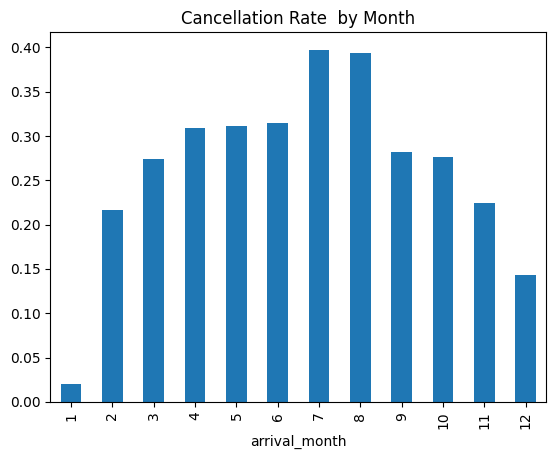

In [32]:
cancel_rate.plot(kind="bar", title="Cancellation Rate  by Month")

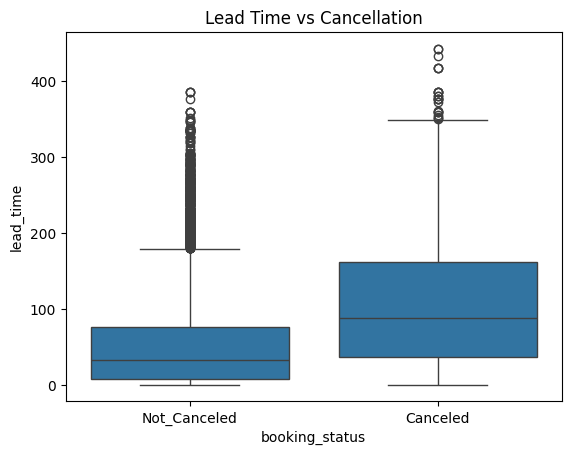

In [33]:
sns.boxplot(data = df, x="booking_status", y="lead_time")
plt.title("Lead Time vs Cancellation")
plt.show()

In [34]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'lead_time', 'arrival_year', 'arrival_month', 'arrival_date',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'total_guests',
       'total_nights'],
      dtype='object')

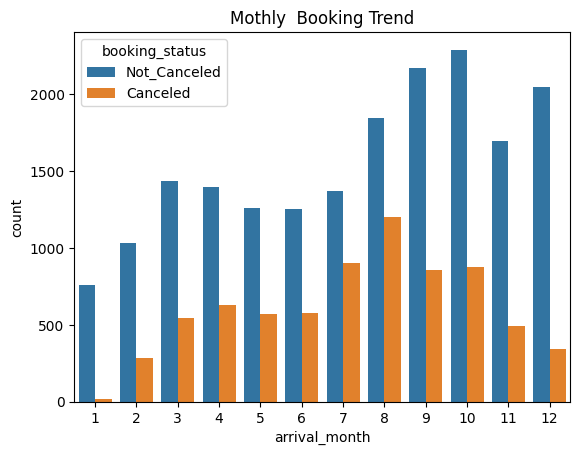

In [35]:
sns.countplot(data=df, x="arrival_month", hue="booking_status")
plt.title("Mothly  Booking Trend")
plt.show()

In [36]:
df["booking_status"] = df["booking_status"].map({
    "Not_Canceled": 1,
    "Canceled": 0
})

để mã hóa (encode) cột trạng thái đặt phòng (booking_status) từ dạng chữ (text) sang dạng số nguyên (integer) để chuẩn bị đưa vào mô hình Machine Learning.

In [37]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,1,2,3
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,1,2,5
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,0,1,3
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,0,2,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,0,4,1
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,1,3,8
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,0,2,4
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,1,2,8


In [38]:
df["is_weekend_headvy"] = (df["no_of_weekend_nights"] > df["no_of_week_nights"]).astype(int)

để tạo một đặc trưng mới (Feature Engineering) mang tên is_weekend_heavy (loại chuyến đi tập trung vào cuối tuần), nhằm phân loại xem khách hàng đi nghỉ dưỡng cuối tuần hay đi công tác/nghỉ dài ngày trong tuần.

In [39]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights,is_weekend_headvy
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,1,2,3,0
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,1,2,5,0
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,0,1,3,1
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,0,2,2,0
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,0,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,0,4,1,0
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,1,3,8,0
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,0,2,4,0
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,1,2,8,0


In [40]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'lead_time', 'arrival_year', 'arrival_month', 'arrival_date',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'total_guests',
       'total_nights', 'is_weekend_headvy'],
      dtype='object')

In [41]:
features = [
    "lead_time",
    "avg_price_per_room",
    "no_of_special_requests",
    "total_guests",
    "total_nights",
    "repeated_guest"
]

In [42]:
X = df[features]

In [43]:
y = df["booking_status"]

In [44]:
X

,lead_time,avg_price_per_room,no_of_special_requests,total_guests,total_nights,repeated_guest
0,224,65.00,0,2,3,0
1,5,106.68,1,2,5,0
2,1,60.00,0,1,3,0
3,211,100.00,0,2,2,0
4,48,94.50,0,2,2,0
...,...,...,...,...,...,...
25806,0,216.00,0,4,1,0
25807,85,167.80,1,3,8,0
25808,228,90.95,2,2,4,0
25809,148,98.39,2,2,8,0


In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

test_size=0.2:

Quyết định tỷ lệ phân chia dữ liệu. Ở đây, 20% dữ liệu sẽ được cắt ra làm tập kiểm thử (X_test, y_test), và 80% dữ liệu còn lại sẽ được dùng làm tập huấn luyện (X_train, y_train).

stratify=y (Cực kỳ quan trọng):

Tham số này đảm bảo rằng tỷ lệ các lớp (classes) trong biến mục tiêu y được giữ nguyên đồng đều ở cả tập train và tập test.

Ví dụ: Nếu ban đầu dữ liệu của bạn có 70% khách không hủy (1) và 30% khách hủy (0), thì khi dùng stratify=y, cả y_train và y_test đều sẽ duy trì xấp xỉ tỷ lệ 70/30 này. Tránh tình trạng vô tình chia ngẫu nhiên khiến tập test chỉ toàn khách không hủy, dẫn đến việc đánh giá mô hình bị sai lệch.

In [47]:
y.value_counts()

booking_status
1    18542
0     7269
Name: count, dtype: int64

In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

from sklearn.utils.class_weight import compute_class_weight:

Nhập (import) hàm chuyên dụng từ thư viện scikit-learn giúp tự động tính toán trọng số quan trọng cho từng lớp (nhóm 0 và nhóm 1).

classes = np.unique(y_train):

y_train: Tập nhãn mục tiêu dùng để huấn luyện mô hình (chứa các giá trị 0 và 1 tương ứng với Hủy và Không hủy).

np.unique(...): Lọc ra các giá trị độc lập (duy nhất) có mặt trong y_train.

Biến classes sau dòng này sẽ lưu một mảng gồm các giá trị phân loại có trong tập train (ví dụ: array([0, 1])).

In [49]:
classes

array([0, 1])

In [50]:
weights = compute_class_weight(class_weight="balanced", classes=classes, y= y_train)

tự động tính toán các hệ số trọng số (class weights) cho từng lớp (0 và 1) dựa trên tần suất xuất hiện của chúng trong tập huấn luyện (y_train).

class_weight="balanced":

Tham số này yêu cầu thư viện tự động tính toán trọng số theo nguyên tắc nghịch đảo với tần suất xuất hiện của lớp.

Cụ thể: Lớp nào ít mẫu hơn (ví dụ: nhóm khách hủy phòng 0 chiếm tỷ lệ thấp) sẽ nhận được trọng số lớn hơn. Ngược lại, lớp nào chiếm đa số (nhóm không hủy phòng 1) sẽ nhận được trọng số nhỏ hơn.

classes=classes:

Truyền vào danh sách các lớp độc lập đã được xác định ở bước trước ([0, 1]) để hàm biết cần tính trọng số cho những nhãn nào.

y=y_train:

Dữ liệu nhãn huấn luyện thực tế để hàm quét qua, đếm số lượng phần tử của từng lớp và thực hiện công thức chia tỷ lệ cân bằng.

In [51]:
weights

array([1.77540843, 0.69601564])

In [52]:
class_weights = dict(zip(classes, weights))

để chuyển đổi danh sách trọng số vừa tính thành một từ điển (dictionary) có dạng khớp giữa nhãn lớp và trọng số tương ứng, giúp các thuật toán học máy dễ dàng đọc và sử dụng.

In [53]:
class_weights

{np.int64(0): np.float64(1.775408426483233),
 np.int64(1): np.float64(0.6960156408009168)}

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier:

Nhập thuật toán Random Forest (Rừng ngẫu nhiên) dạng phân loại (Classifier).

Đây là một thuật toán học máy tập hợp (Ensemble Learning) rất mạnh, hoạt động bằng cách kết hợp nhiều cây quyết định (Decision Trees) nhỏ lẻ lại với nhau để đưa ra dự đoán cuối cùng, giúp hạn chế hiện tượng quá khớp (overfitting) và mang lại độ chính xác cao cho bài toán dự đoán hủy phòng.

from sklearn.model_selection import RandomizedSearchCV:

Nhập công cụ Randomized Search Cross-Validation.

Thay vì phải thử tất cả mọi tổ hợp tham số có thể (rất tốn thời gian như GridSearch), công cụ này sẽ lấy ngẫu nhiên một số lượng giới hạn các cấu hình tham số trong khoảng bạn định nghĩa để tìm ra bộ thông số tối ưu nhất cho mô hình Random Forest thông qua kỹ thuật kiểm định chéo (Cross-Validation).

In [55]:
rf = RandomForestClassifier(class_weight=class_weights)

dùng để khởi tạo mô hình Random Forest Classifier và tích hợp trực tiếp trọng số lớp (class_weights) mà bạn đã tính toán trước đó vào trong mô hình.

class_weight=class_weights:

Truyền từ điển trọng số lớp (ví dụ: {0: trọng_số_cho_khách_hủy, 1: trọng_số_cho_khách_giữ}) vào mô hình.

Nhờ tham số này, khi mô hình Random Forest tiến hành xây dựng các cây quyết định bên trong, nó sẽ tự động nhận biết nhóm khách hàng hủy phòng (0) đang có trọng số lớn hơn, từ đó tập trung học các đặc trưng của nhóm này kỹ hơn để tránh bỏ sót.

In [56]:
rf_params = {
    "n_estimators": [100,200,300],
    "max_depth": [5,10,20,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

định nghĩa không gian siêu tham số (hyperparameter grid) mà RandomizedSearchCV sẽ sử dụng để quét qua và tìm ra cấu hình tốt nhất cho mô hình RandomForestClassifier.

"n_estimators": [100, 200, 300]:

Số lượng cây quyết định (decision trees) sẽ được tạo ra trong "rừng". Nhiều cây hơn thường giúp mô hình ổn định và chính xác hơn, nhưng thời gian huấn luyện sẽ lâu hơn.

max_depth": [5, 10, 20, None]:

Độ sâu tối đa cho mỗi cây quyết định.

Giới hạn độ sâu (như 5 hoặc 10) giúp ngăn chặn hiện tượng quá khớp (overfitting), trong khi None cho phép cây phát triển tự do cho đến khi phân loại hoàn toàn các mẫu trên tập huấn luyện.


"min_samples_split": [2, 5, 10]:

Số lượng mẫu tối thiểu cần thiết để một nút (node) trong cây có thể tiếp tục tách nhánh. Giá trị lớn hơn giúp mô hình tổng quát hóa tốt hơn, tránh việc học thuộc lòng dữ liệu nhiễu.

"min_samples_leaf": [1, 2, 4]:

Số lượng mẫu tối thiểu phải có ở mỗi nút lá (leaf node). Điều này cũng đóng vai trò kiểm soát độ phức tạp của cây và chống overfitting.


In [57]:
rf_random = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    n_jobs=1
)

khởi tạo và cấu hình đối tượng RandomizedSearchCV, sẵn sàng cho quá trình tìm kiếm ngẫu nhiên các siêu tham số tốt nhất cho mô hình Random Forest.

rf: Mô hình cơ sở (RandomForestClassifier) đã được tích hợp sẵn trọng số lớp (class_weight) ở các bước trước.

rf_params: Không gian chứa các khoảng giá trị siêu tham số mà chúng ta đã định nghĩa để mô hình quét qua.

n_iter=20: Số lượng tổ hợp tham số ngẫu nhiên sẽ được chọn ra để thử nghiệm. Thay vì thử hết tất cả các khả năng (như Grid Search), thuật toán sẽ chỉ lấy ngẫu nhiên 20 cấu hình khác nhau để tiết kiệm thời gian.

cv=3: Số lượng phần trong Cross-Validation (Kiểm định chéo) (3 folds). Dữ liệu huấn luyện sẽ được chia thành 3 phần, mô hình sẽ được huấn luyện trên 2 phần và kiểm tra trên 1 phần còn lại, lặp lại 3 lần để lấy điểm trung bình đánh giá độ ổn định.

scoring="accuracy": Tiêu chí dùng để đánh giá và so sánh các cấu hình tham số là độ chính xác tổng thể (accuracy). (Lưu ý nhỏ: Vì bài toán của bạn có dữ liệu mất cân bằng, đôi khi các chỉ số như roc_auc hoặc f1 sẽ phản ánh chất lượng tốt hơn accuracy, nhưng accuracy vẫn là một khởi đầu phổ biến).

n_jobs=1: Số lượng nhân CPU được sử dụng để chạy song song. (Mẹo nhỏ: Bạn có thể đổi thành n_jobs=-1 để tận dụng toàn bộ nhân CPU của máy tính, giúp quá trình chạy tìm kiếm diễn ra nhanh hơn đáng kể).

In [58]:
rf_random.fit(X_train, y_train)

,estimator,RandomForestC...56408009168)})
,param_distributions,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [59]:
rf_random.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 20}

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

nhập và khởi tạo mô hình Gradient Boosting Classifier, một thuật toán học tập kết hợp (Ensemble Learning) rất mạnh mẽ khác bên cạnh Random Forest.

In [61]:
gb_params = {
    "n_estimators": [100,200],
    "learning_rate": [0.01,0.1,0.2],
    "max_depth": [3,5,7]
}

In [62]:
gb_random = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=15,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [63]:
gb_random.fit(X_train, y_train)

,estimator,GradientBoostingClassifier()
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,n_iter,15
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [66]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   --- ------------------------------------ 3.9/48.9 MB 19.7 MB/s eta 0:00:03
   ----- ---------------------------------- 7.1/48.9 MB 18.4 MB/s eta 0:00:03
   -------- ------------------------------- 10.5/48.9 MB 17.8 MB/s eta 0:00:03
   ---------- ----------------------------- 12.8/48.9 MB 16.1 MB/s eta 0:00:03
   ----------- ---------------------------- 13.9/48.9 MB 13.8 MB/s eta 0:00:03
   ----------- ---------------------------- 14.4/48.9 MB 12.8 MB/s eta 0:00:03
   ------------ --------------------------- 15.2/48.9 MB 10.6 MB/s eta 0:00:04
   ------------- -------------------------- 16.0/48.9 MB 9.8 MB/s eta 0:00:04
   ------------- -------------------------- 16.3/48.9 MB 9.3 MB/s eta 0:00:04
   ------------- -------------------------- 16.5/48.9 MB 8.3 MB/s eta 0:00:04
   ------------- -------------------------- 16.8/48.9 MB 7.4 MB/s eta 0:00:

In [67]:

from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight = class_weights[0] / class_weights[1],
    eval_metric = "logloss"
)

nhập và khởi tạo mô hình XGBoost Classifier, một trong những thuật toán học máy mạnh mẽ và phổ biến nhất hiện nay, đồng thời cấu hình cách xử lý dữ liệu mất cân bằng.

Nhập thuật toán XGBoost (Extreme Gradient Boosting) từ thư viện ngoài xgboost. Đây là một thuật toán dựa trên nền tảng Gradient Boosting nhưng được tối ưu hóa cực tốt về tốc độ và hiệu suất, thường xuyên đạt kết quả cao trong các bài toán dự đoán thực tế.


scale_pos_weight = class_weights[0] / class_weights[1]:

Cách XGBoost xử lý mất cân bằng: Khác với RandomForest (dùng dictionary class_weight), XGBoost sử dụng tham số độc lập scale_pos_weight để cân bằng tỷ lệ giữa lớp dương (positive class) và lớp âm (negative class).

Ý nghĩa công thức: Bằng cách lấy trọng số của lớp 0 chia cho lớp 1 (từ từ điển class_weights bạn đã tính trước đó), bạn đang cung cấp cho XGBoost hệ số nhân chính xác để tăng mức độ quan tâm của mô hình đối với nhóm khách hàng hủy phòng (0), giúp khắc phục triệt để hiện tượng lệch dữ liệu.

In [68]:
xgb_params = {
    "n_estimators": [100,200,300],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.1,0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7,1.0]
}

In [69]:
xgb_random = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [70]:
xgb_random.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [71]:
from sklearn.metrics import accuracy_score

In [72]:
models = {
    "RandomForest": rf_random,
    "GradientBoosting": gb_random.best_estimator_,
    "XGBoost": xgb_random.best_estimator_
}

In [73]:
for name, model in models.items():
    print(f"{name}")
    y_pred = model.predict(X_test)
    print(accuracy_score(y_test, y_pred))

RandomForest
0.8086383885337982
GradientBoosting
0.8295564594228162
XGBoost
0.8125121053650978


In [74]:
import joblib

best_model = gb_random.best_estimator_

In [75]:
joblib.dump(best_model, "gb_booking_model.pkl")

['gb_booking_model.pkl']

In [ ]:
features

['lead_time',
 'avg_price_per_room',
 'no_of_special_requests',
 'total_guests',
 'total_nights',
 'repeated_guest']

In [76]:
import sklearn

print(sklearn.__version__)

1.7.0
